# ✈️ Flight Price Prediction in India - Machine Learning & Data Science

<img src="https://images.unsplash.com/photo-1530521954074-e64f6810b32d?q=80&w=2070&auto=format&fit=crop" width="800" alt="Aviation Background">

## 📋 About the Dataset
This project utilizes a comprehensive dataset containing information about domestic flight booking options in India. The dataset consists of over **300,000 data points** and **11 features**, capturing crucial details such as the airline, flight duration, number of stops, class, and the days left until departure.

**Goal:** The primary objective of this project is to perform Exploratory Data Analysis (EDA) to uncover pricing patterns and to build robust Machine Learning models capable of accurately predicting flight ticket prices (in INR).

**Source**: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction/data

## 1. Uploading data

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [123]:
df = pd.read_csv('flightDataset.csv')
df = df.drop(['Unnamed: 0'], axis=1)

## 2. Preprocessing

In [124]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [126]:
df.shape

(300153, 11)

In [127]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


The dataset is remarkably clean with no missing values (`NaN`). Therefore, no data imputation or dropping of rows is necessary at this stage.



In [128]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


A quick statistical overview (`describe`) reveals no illogical values or extreme outliers that would distort our models. The distributions appear valid, and the data is ready for further analysis.



In [129]:
df[df.duration==49.83]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
193889,Air_India,AI-672,Chennai,Evening,two_or_more,Evening,Bangalore,Economy,49.83,2,23891
194359,Air_India,AI-672,Chennai,Evening,one,Evening,Bangalore,Economy,49.83,9,17538


Upon investigating the maximum flight duration (nearly 50 hours), it is evident that these correspond to flights with one or multiple stops (`two_or_more`). This is practically plausible for connecting flights, so these records are retained.

In [130]:
df.airline.unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

The dataset covers the domestic aviation market in India, featuring 6 major airlines, representing a mix of low-cost carriers (e.g., Indigo, AirAsia) and full-service airlines (e.g., Vistara, Air India).

In [131]:
df.source_city.unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

Route coverage is focused on 6 major metropolitan economic hubs in India, serving as both source and destination cities.

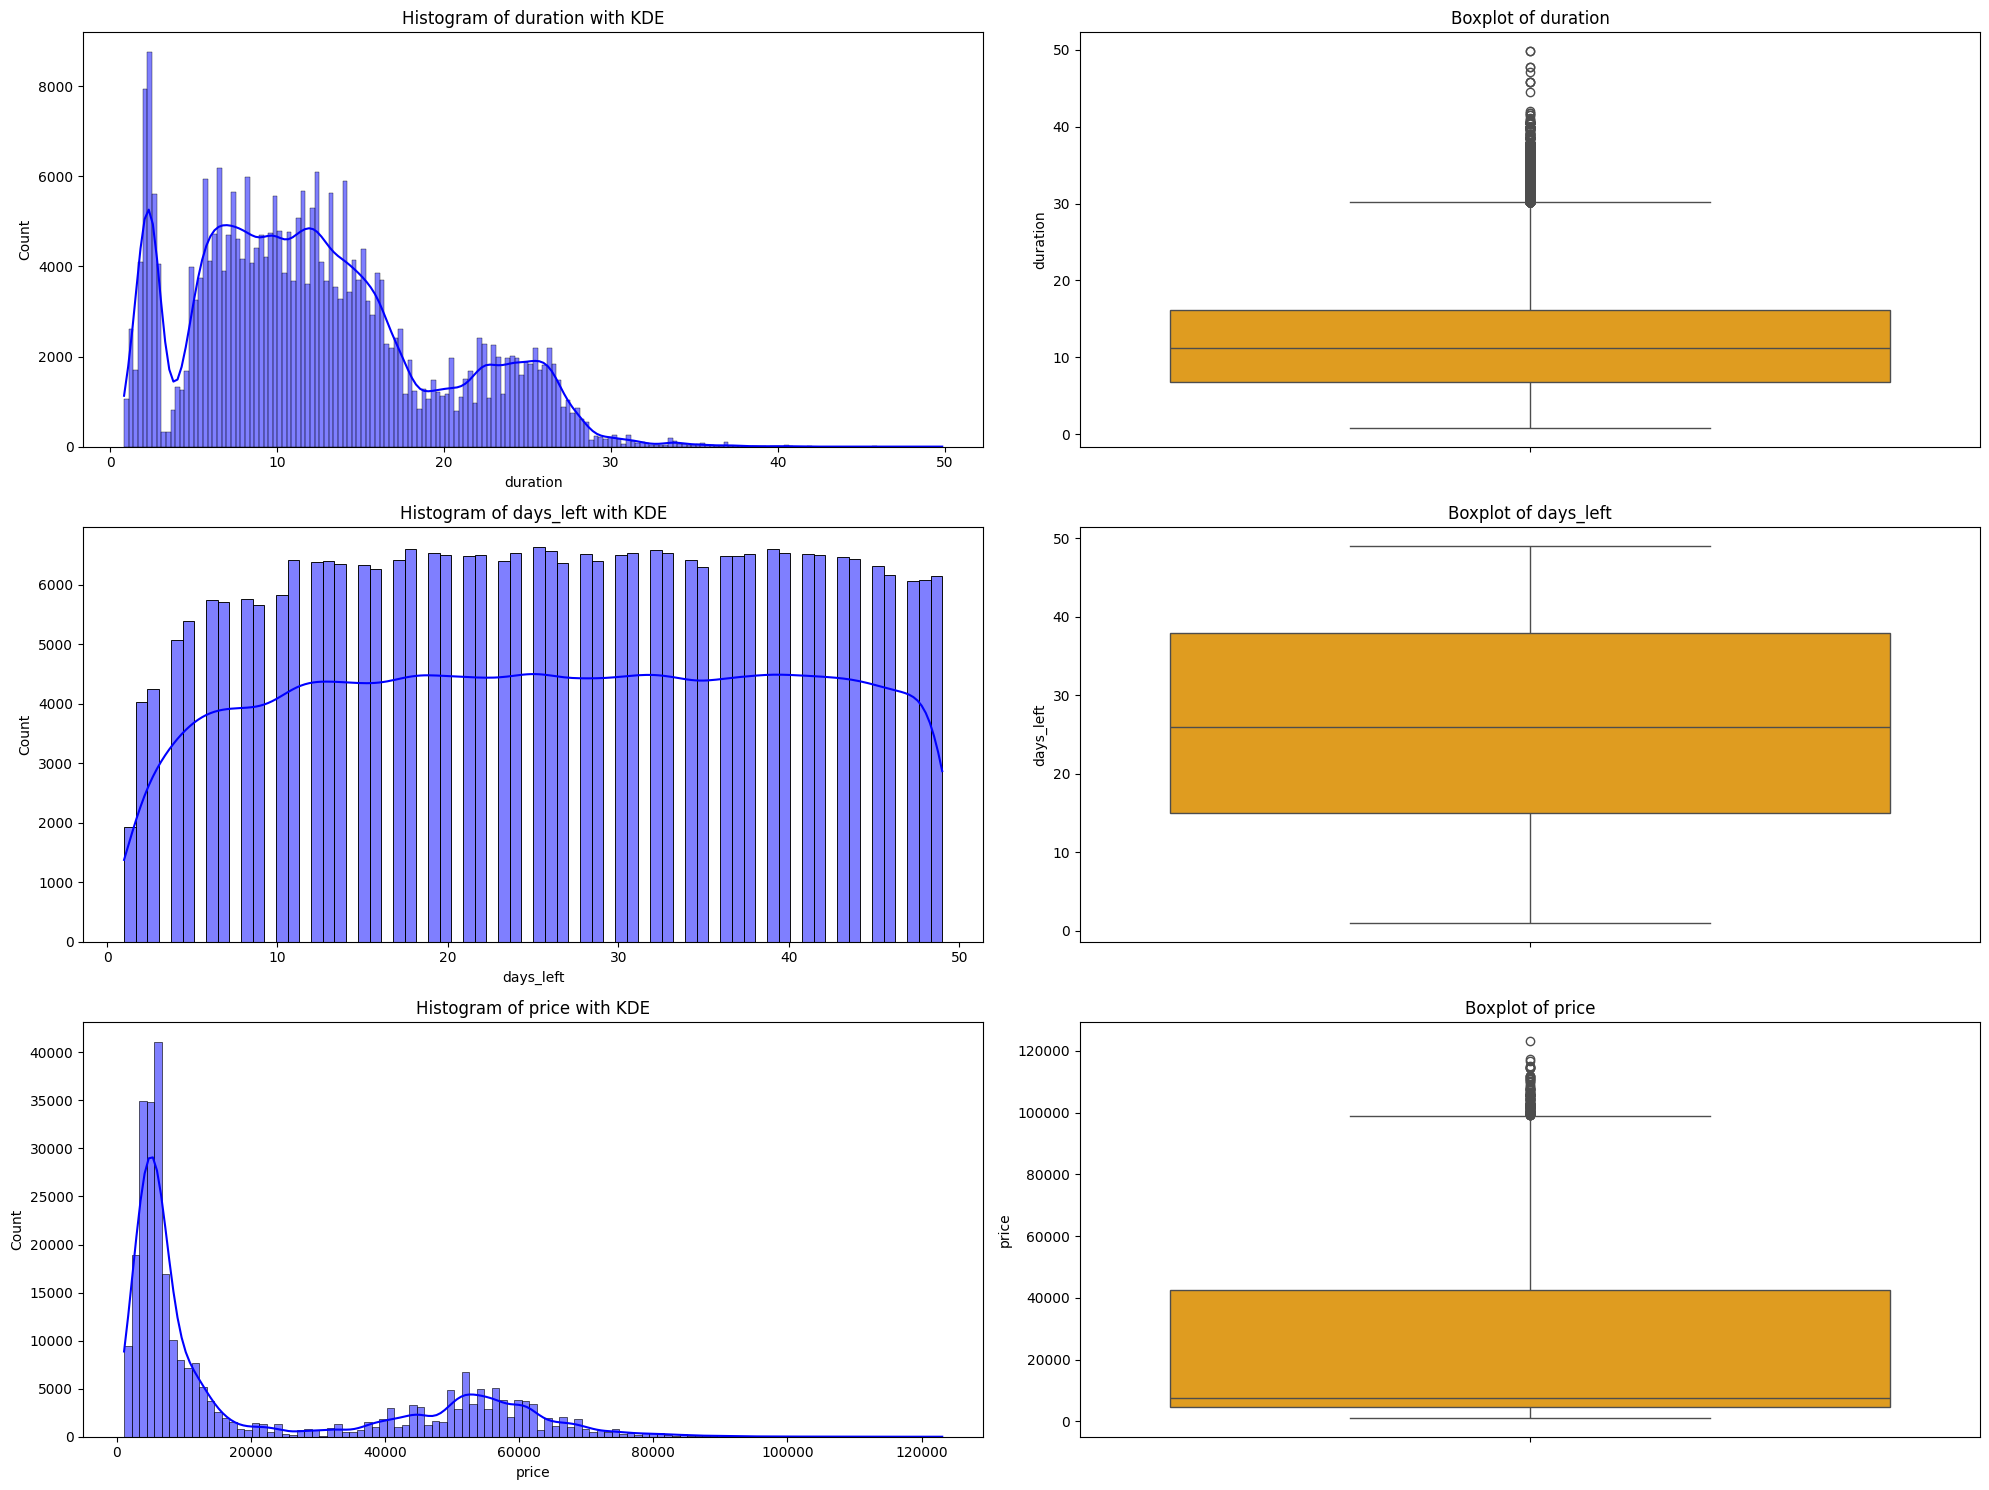

In [132]:
num_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(len(num_cols), 2, figsize=(20, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
  sns.histplot(df[col], ax=axes[i,0], color='blue', kde=True)
  axes[i,0].set_title(f'Histogram of {col} with KDE')
  sns.boxplot(df[col], ax=axes[i,1], color='orange')
  axes[i,1].set_title(f'Boxplot of {col}')

plt.tight_layout()

As seen on the plot with boxplots and histograms of numerical columns above:
* *Duration* values are unevenly distributed due to a lot of flights with stops (long waiting for the second mid-flight) - reason for outliers,
* *Days_left* - there are not any outliers, because there is similar count of flight bought earlier as these bought later - histogram with fair distribution,
* *Price* - there is a huge amount of cheap tickets and smaller count of these more expensive, which indicates fact that people bought mostly flight tickets in economy class (smaller price) - outliers on boxplot show business class.

In [133]:
df2 = df.drop(['flight'], axis=1)
df2.head(10)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


### Feature Selection
The `flight` column (flight number) acts as a unique identifier for individual trips and does not provide any predictive value for the generalized pricing patterns. Therefore, it is dropped to prevent the model from learning noise and to reduce dimensionality.

In [134]:
cat_cols = ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time']
ord_cols = ['stops', 'class']

stops_order = ['zero', 'one', 'two_or_more']
class_order = ['Economy', 'Business']

In [135]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[stops_order, class_order]), ord_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)
df_proces = preprocessor.fit_transform(df2)

cols = preprocessor.get_feature_names_out()
df_final = pd.DataFrame(df_proces, columns=cols)

In [136]:
df_final.head()

,ord__stops,ord__class,cat__airline_Air_India,cat__airline_GO_FIRST,cat__airline_Indigo,cat__airline_SpiceJet,cat__airline_Vistara,cat__source_city_Chennai,cat__source_city_Delhi,cat__source_city_Hyderabad,...,cat__departure_time_Morning,cat__departure_time_Night,cat__arrival_time_Early_Morning,cat__arrival_time_Evening,cat__arrival_time_Late_Night,cat__arrival_time_Morning,cat__arrival_time_Night,remainder__duration,remainder__days_left,remainder__price
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.17,1.0,5953.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.33,1.0,5953.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.17,1.0,5956.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.25,1.0,5955.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.33,1.0,5955.0


### Categorical Data Encoding
Machine Learning algorithms require numerical input. Since our dataset contains multiple categorical features of type `string`, we must apply appropriate encoding techniques:

* **Nominal Features** (`airline`, `source_city`, `destination_city`, `departure_time`, `arrival_time`): These variables do not have an inherent intrinsic order. We apply **One-Hot Encoding** (dropping the first column to avoid the dummy variable trap/multicollinearity).
* **Ordinal Features** (`stops`, `class`): These variables have a clear hierarchical order that directly correlates with the ticket price (e.g., 'Business' class is inherently more expensive than 'Economy'). We apply **Ordinal Encoding** to preserve this ranking mathematically.

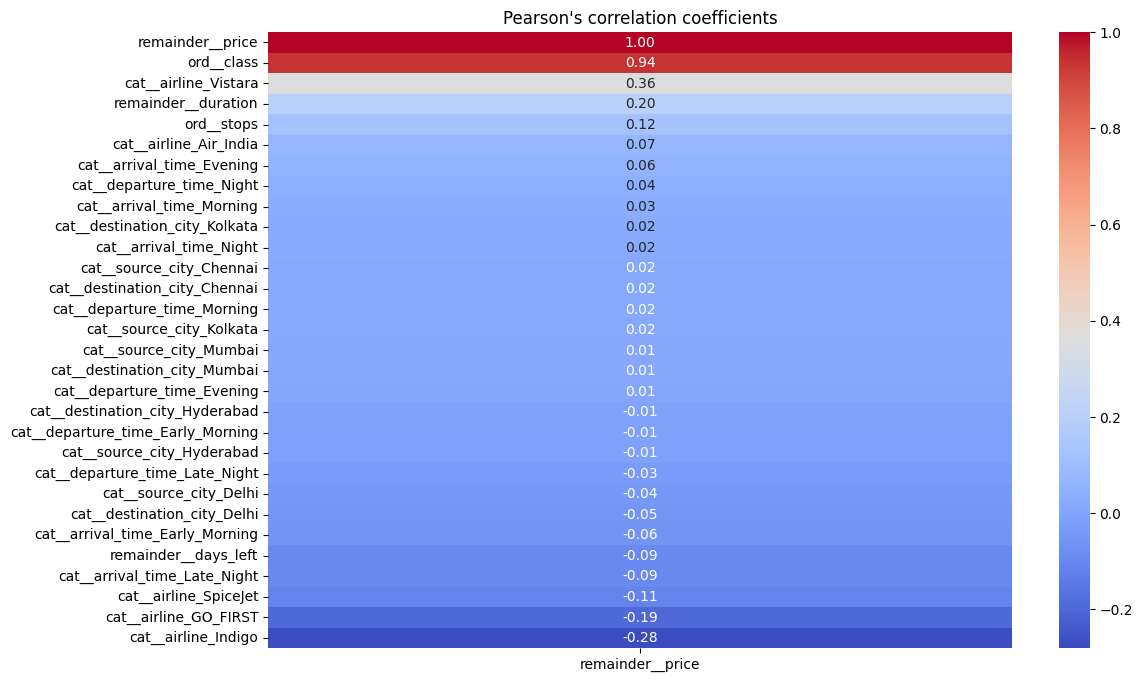

In [137]:
cor_matrix = df_final.corr()[['remainder__price']].sort_values(by='remainder__price', ascending=False)
plt.figure(figsize=(12,8))
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Pearson's correlation coefficients")
plt.show()

As seen above in Pearson's correlation coefficients matrix with *price*, only few columns had siginificantly higher correlation with target value (*price*) - *ord_class* - flight class, some specific airlines - *Vistara*, *Indigo* or *GO_FIRST*, *duration* of a flight. The rest is skippable for creating models (to not to making mistakes during training).

### Including route - from **source** to **destination**

In [138]:
df3 = df2
df3['route'] = df3.source_city + '-' + df3.destination_city
df3 = df3.drop(['source_city', 'destination_city'], axis=1)
df3.head(10)

,airline,departure_time,stops,arrival_time,class,duration,days_left,price,route
0,SpiceJet,Evening,zero,Night,Economy,2.17,1,5953,Delhi-Mumbai
1,SpiceJet,Early_Morning,zero,Morning,Economy,2.33,1,5953,Delhi-Mumbai
2,AirAsia,Early_Morning,zero,Early_Morning,Economy,2.17,1,5956,Delhi-Mumbai
3,Vistara,Morning,zero,Afternoon,Economy,2.25,1,5955,Delhi-Mumbai
4,Vistara,Morning,zero,Morning,Economy,2.33,1,5955,Delhi-Mumbai
5,Vistara,Morning,zero,Afternoon,Economy,2.33,1,5955,Delhi-Mumbai
6,Vistara,Morning,zero,Morning,Economy,2.08,1,6060,Delhi-Mumbai
7,Vistara,Afternoon,zero,Evening,Economy,2.17,1,6060,Delhi-Mumbai
8,GO_FIRST,Early_Morning,zero,Morning,Economy,2.17,1,5954,Delhi-Mumbai
9,GO_FIRST,Afternoon,zero,Evening,Economy,2.25,1,5954,Delhi-Mumbai


### Feature Engineering: Route Generation
To capture potential interactions between the departure and arrival locations, a new composite feature named `route` is generated by concatenating `source_city` and `destination_city`. The original isolated city columns are then removed to test if the specific flight path holds higher predictive power than the cities evaluated independently.

In [139]:
cat_cols2 = ['airline', 'route', 'departure_time', 'arrival_time']

In [140]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[stops_order, class_order]), ord_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols2)
    ],
    remainder='passthrough'
)
df_proces2 = preprocessor2.fit_transform(df3)

cols2 = preprocessor2.get_feature_names_out()
df_final2 = pd.DataFrame(df_proces2, columns=cols2)

In [141]:
df_final2.head()

,ord__stops,ord__class,cat__airline_Air_India,cat__airline_GO_FIRST,cat__airline_Indigo,cat__airline_SpiceJet,cat__airline_Vistara,cat__route_Bangalore-Delhi,cat__route_Bangalore-Hyderabad,cat__route_Bangalore-Kolkata,...,cat__departure_time_Morning,cat__departure_time_Night,cat__arrival_time_Early_Morning,cat__arrival_time_Evening,cat__arrival_time_Late_Night,cat__arrival_time_Morning,cat__arrival_time_Night,remainder__duration,remainder__days_left,remainder__price
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.17,1.0,5953.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.33,1.0,5953.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.17,1.0,5956.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.25,1.0,5955.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.33,1.0,5955.0


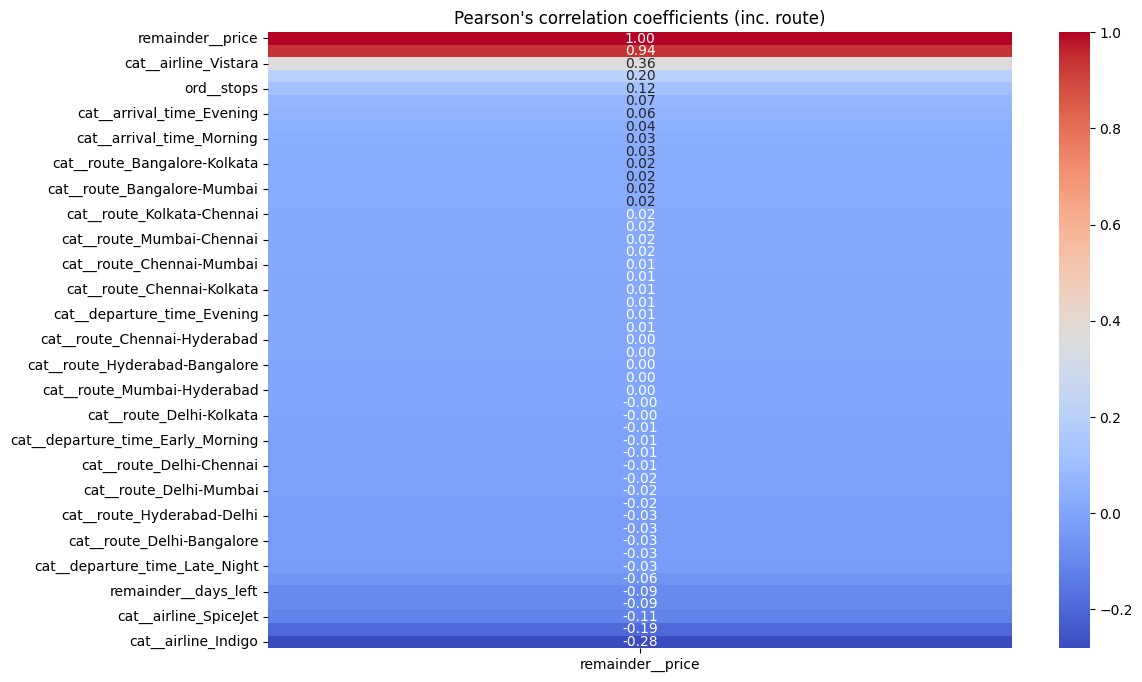

In [142]:
cor_matrix2 = df_final2.corr()[['remainder__price']].sort_values(by='remainder__price', ascending=False)
plt.figure(figsize=(12,8))
sns.heatmap(cor_matrix2, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Pearson's correlation coefficients (inc. route)")
plt.show()

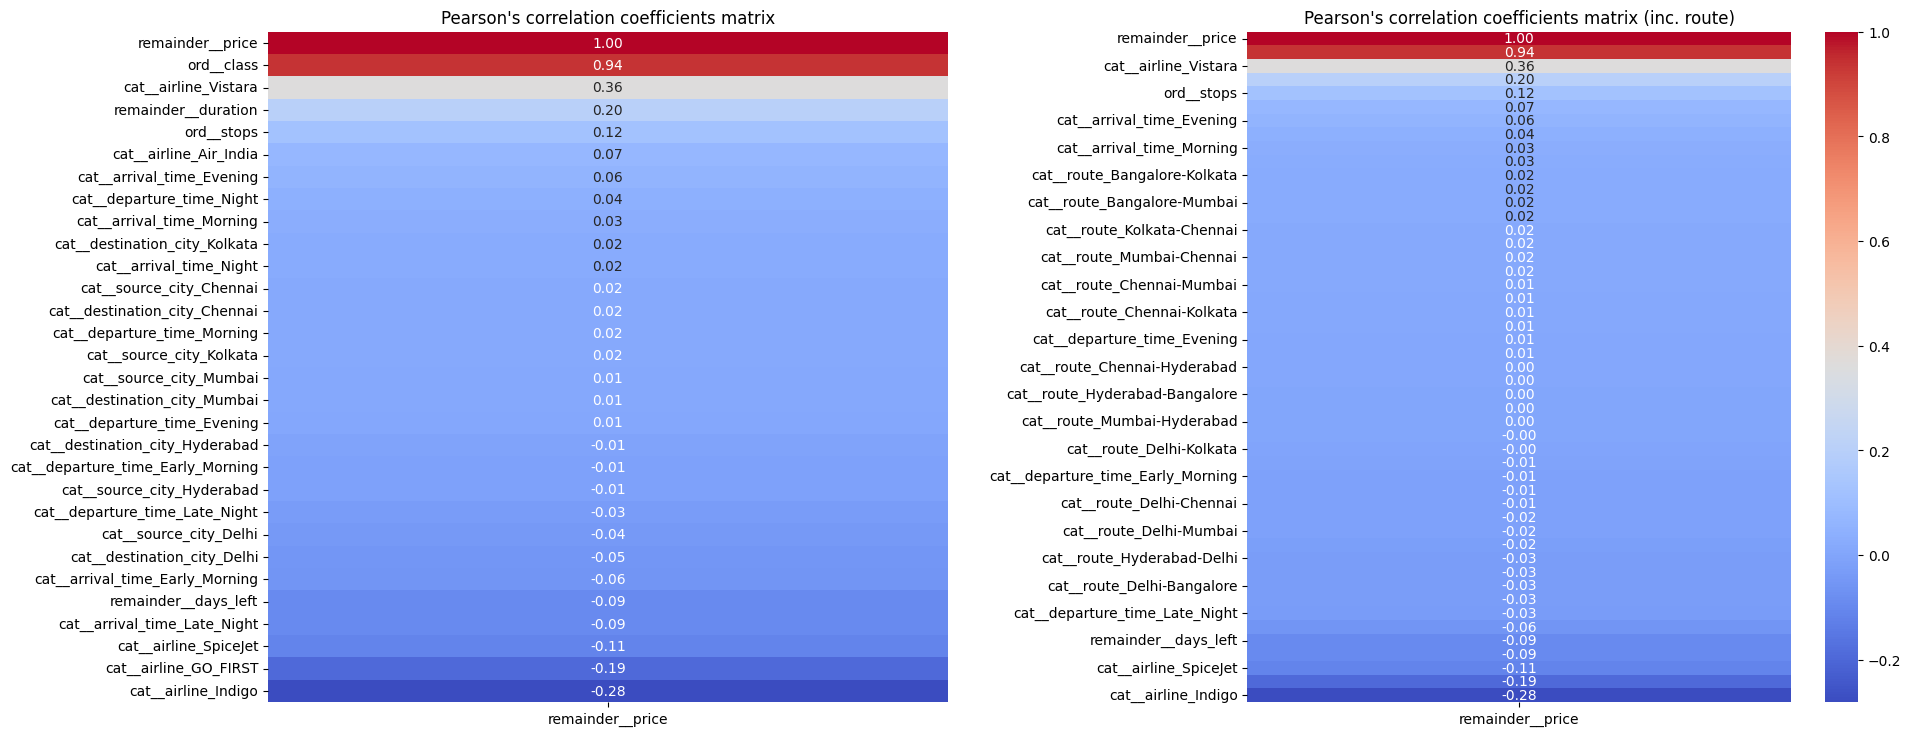

In [143]:
fig, axes = plt.subplots(1,2,figsize=(20,8))
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[0], cbar=False)
axes[0].set_title("Pearson's correlation coefficients matrix")
sns.heatmap(cor_matrix2, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1])
axes[1].set_title("Pearson's correlation coefficients matrix (inc. route)")
plt.tight_layout(pad=3.0)
plt.show()

### Correlation Analysis & Conclusion
A comparative analysis of the Pearson's correlation matrices reveals that the engineered `route` feature does not exhibit a significantly higher correlation with `price` than the individual `source_city` and `destination_city` columns.

**Decision:** To adhere to the principle of model simplicity and to keep dimensionality low, the `route` feature is discarded. We will proceed with the original dataset architecture for model training.

In [144]:
df_final.columns

Index(['ord__stops', 'ord__class', 'cat__airline_Air_India',
       'cat__airline_GO_FIRST', 'cat__airline_Indigo', 'cat__airline_SpiceJet',
       'cat__airline_Vistara', 'cat__source_city_Chennai',
       'cat__source_city_Delhi', 'cat__source_city_Hyderabad',
       'cat__source_city_Kolkata', 'cat__source_city_Mumbai',
       'cat__destination_city_Chennai', 'cat__destination_city_Delhi',
       'cat__destination_city_Hyderabad', 'cat__destination_city_Kolkata',
       'cat__destination_city_Mumbai', 'cat__departure_time_Early_Morning',
       'cat__departure_time_Evening', 'cat__departure_time_Late_Night',
       'cat__departure_time_Morning', 'cat__departure_time_Night',
       'cat__arrival_time_Early_Morning', 'cat__arrival_time_Evening',
       'cat__arrival_time_Late_Night', 'cat__arrival_time_Morning',
       'cat__arrival_time_Night', 'remainder__duration',
       'remainder__days_left', 'remainder__price'],
      dtype='object')

In [145]:
df_ready = df_final.loc[:,['ord__class', 'cat__airline_Vistara', 'cat__airline_Indigo', 'remainder__duration', 'cat__airline_GO_FIRST', 'remainder__price']]

### Preparing chosen dataset for deploying models

In [146]:
X = df_ready.drop(['remainder__price'], axis=1)
y = df_ready['remainder__price']

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [148]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [149]:
(X_train.shape, y_test.shape)

((240122, 5), (60031,))

## Models

### Linear Regression 1

In [150]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [151]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'R^2 Score: {r2_score(y_test, y_pred):.4f}')
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R^2 Score: 0.8919
MAE: 4742.82
RMSE: 7465.95


### Linear Regression 2

In [152]:
df_ready2 = df_final.loc[:,['ord__class', 'ord__stops', 'remainder__days_left', 'cat__airline_Vistara', 'cat__airline_Indigo', 'remainder__duration', 'cat__airline_GO_FIRST', 'remainder__price']]

X2 = df_ready2.drop(['remainder__price'], axis=1)
y2 = df_ready2['remainder__price']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, random_state=42, test_size=0.2)

scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train2)
X_test_scaled2 = scaler2.transform(X_test2)

In [153]:
model2 = LinearRegression()
model2.fit(X_train_scaled2, y_train2)

y_pred2 = model2.predict(X_test_scaled2)

print(f'R^2 Score: {r2_score(y_test2, y_pred2):.4f}')
print(f"MAE: {mean_absolute_error(y_test2, y_pred2):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred2)):.2f}")

R^2 Score: 0.9057
MAE: 4532.71
RMSE: 6973.68


### Baseline Model: Linear Regression
The initial Linear Regression model, utilizing a restricted set of variables, established a solid baseline with an **R² score of 0.89**. Reintroducing contextual features like `days_left` and `stops` into the dataset further improved the R² score to 0.90.

However, a critical observation must be made regarding the error metrics. The disproportionately high **RMSE (Root Mean Squared Error)** of approximately 7,000 INR—compared to the MAE—acts as a statistical red flag. It indicates that the linear model struggles significantly with extreme values (outliers), failing to accurately capture the non-linear, steep pricing tiers inherently associated with Business Class tickets.

### Linear Regression - Performance Analysis
The baseline Linear Regression model provides a decent starting point. However, the notable discrepancy between the **MAE (Mean Absolute Error)** and **RMSE (Root Mean Squared Error)** indicates that the model is making significantly large errors on specific data points (likely the expensive Business class flights). Linear models assume constant proportional changes, which fails to reflect the discrete, step-like pricing strategies implemented by airlines.

To overcome this limitation and better handle outliers without extensive data transformation, we will transition to ensemble methods.

### Random Forest Regression 1

In [154]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [155]:
print(f"RF R^2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"RF MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RF RMSE: {np.sqrt(((y_test - y_pred_rf) ** 2).mean()):.2f}")

RF R^2 Score: 0.9395
RF MAE: 3652.14
RF RMSE: 5583.83


### Model Comparison: Random Forest vs. Linear Regression

The **Random Forest Regressor** significantly outperforms the baseline Linear Regression model. The fundamental reason for this improvement lies in the algorithm's ability to capture **non-linear relationships** within the data.

While Linear Regression struggled with extreme values (outliers) predominantly associated with the highly-priced 'Business Class' tickets, the decision tree-based architecture of Random Forest successfully isolated and modeled these complex pricing tiers. This is quantitatively confirmed by a substantial decrease in the **RMSE (Root Mean Squared Error)** to 5583.83 and an improvement in the **R² Score** to 0.9395.

### Random Forest Regression 2

In [156]:
rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model2.fit(X_train_scaled2, y_train2)
y_pred_rf2 = rf_model2.predict(X_test_scaled2)

In [157]:
print(f"RF R^2 Score: {r2_score(y_test2, y_pred_rf2):.4f}")
print(f"RF MAE: {mean_absolute_error(y_test2, y_pred_rf2):.2f}")
print(f"RF RMSE: {np.sqrt(((y_test2 - y_pred_rf2) ** 2).mean()):.2f}")

RF R^2 Score: 0.9349
RF MAE: 3361.08
RF RMSE: 5794.53


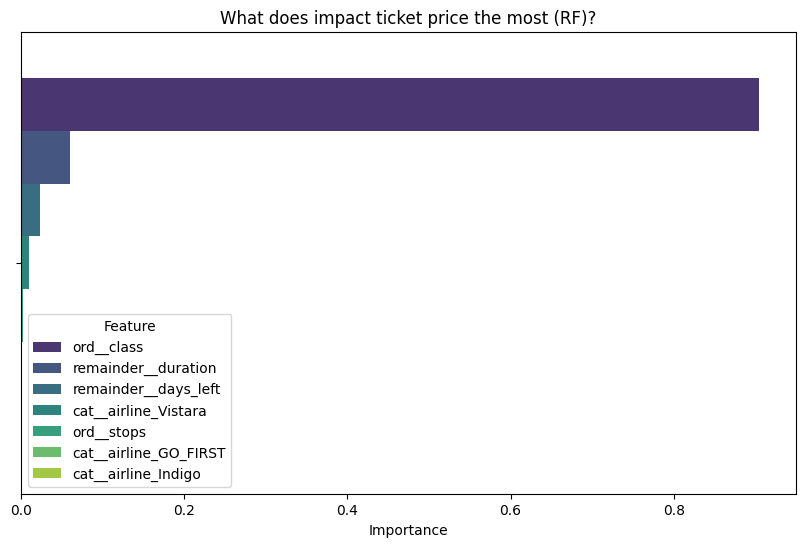

In [158]:
importances2 = rf_model2.feature_importances_
feature_names2 = X_train2.columns
feature_importance_df2 = pd.DataFrame({'Feature': feature_names2, 'Importance': importances2})
feature_importance_df2 = feature_importance_df2.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', hue='Feature', data=feature_importance_df2, palette='viridis')
plt.title('What does impact ticket price the most (RF)?')
plt.show()

The second model of Random Forest Regression gave a little bit smaller R^2 score and higher RMSE, but significantly lower MAE score (3361.08) comparing to the previous one. As far as I am concerned, in business problems like this one, MAE coefficient is the most vital. Beside that, R^2 score was still very high, but not that high that could cause overfitting problem. As seen above on the plot, ticket price is determined mostly by *class* (*Economy* or *Business*), a bit by *duration* and a little by *days_left* and choosing *Vistara airline*.

### XGBoost model 1 using GridSearchCV

In [159]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'max_depth': [3,5,6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 500]
}
grid = GridSearchCV(XGBRegressor(), param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2)

grid.fit(X_train_scaled2, y_train2)
print(f'Best XGB params: {grid.best_params_}')

best_model = grid.best_estimator_
y_pred3 = best_model.predict(X_test_scaled2)

print(f"XGB R^2 Score: {r2_score(y_test2, y_pred3):.4f}")
print(f"XGB MAE: {mean_absolute_error(y_test2, y_pred3):.2f}")
print(f"XGB RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred3)):.2f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best XGB params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500}
XGB R^2 Score: 0.9508
XGB MAE: 2946.57
XGB RMSE: 5038.50


### XGBoost model 2 with early stopping

In [160]:
xg_model2 = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.5,
    max_depth=8,
    early_stopping_rounds=50,
    random_state=42
)

xg_model2.fit(X_train_scaled2, y_train2,eval_set=[(X_test_scaled2, y_test2)], verbose=100)

y_pred4 = xg_model2.predict(X_test_scaled2)

print(f"Trees amount: {xg_model2.best_iteration}")
print(f"XGB2 R^2 Score: {r2_score(y_test2, y_pred4):.4f}")
print(f"XGB2 MAE: {mean_absolute_error(y_test2, y_pred4):.2f}")
print(f"XGB2 RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred4)):.2f}")

[0]	validation_0-rmse:12255.07753
[78]	validation_0-rmse:5145.25466
Trees amount: 28
XGB2 R^2 Score: 0.9499
XGB2 MAE: 2970.88
XGB2 RMSE: 5080.37


### XGBoost model 3 with early stopping

In [161]:
xg_model3 = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=6,
    early_stopping_rounds=100,
    random_state=42
)

xg_model3.fit(X_train_scaled2, y_train2,eval_set=[(X_test_scaled2, y_test2)], verbose=100)

y_pred5 = xg_model3.predict(X_test_scaled2)

print(f"Trees amount: {xg_model3.best_iteration}")
print(f"XGB2 R^2 Score: {r2_score(y_test2, y_pred5):.4f}")
print(f"XGB2 MAE: {mean_absolute_error(y_test2, y_pred5):.2f}")
print(f"XGB2 RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred5)):.2f}")

[0]	validation_0-rmse:22490.16185
[100]	validation_0-rmse:9632.44899
[200]	validation_0-rmse:6088.80232
[300]	validation_0-rmse:5411.40101
[400]	validation_0-rmse:5283.64698
[500]	validation_0-rmse:5243.92127
[600]	validation_0-rmse:5217.42290
[700]	validation_0-rmse:5194.49137
[800]	validation_0-rmse:5176.55199
[900]	validation_0-rmse:5160.82320
[1000]	validation_0-rmse:5144.05619
[1100]	validation_0-rmse:5131.74155
[1200]	validation_0-rmse:5121.58390
[1300]	validation_0-rmse:5114.79547
[1400]	validation_0-rmse:5110.03182
[1500]	validation_0-rmse:5105.09151
[1600]	validation_0-rmse:5097.90676
[1700]	validation_0-rmse:5091.83070
[1800]	validation_0-rmse:5086.07492
[1900]	validation_0-rmse:5081.77459
[2000]	validation_0-rmse:5077.76754
[2100]	validation_0-rmse:5073.57918
[2200]	validation_0-rmse:5070.71281
[2300]	validation_0-rmse:5068.57819
[2400]	validation_0-rmse:5064.03769
[2500]	validation_0-rmse:5060.50136
[2600]	validation_0-rmse:5058.19543
[2700]	validation_0-rmse:5055.49846
[28

In [162]:
final_model = best_model

### Advanced Ensemble: XGBoost Regressor & Hyperparameter Tuning
To push the predictive boundaries further, an **XGBoost Regressor** was implemented. To ensure optimal configuration and avoid manual trial-and-error, **GridSearchCV** was utilized for systematic hyperparameter tuning. This rigorous approach yielded outstanding results, breaking the 3,000 INR barrier for the first time with an **MAE of 2,946 INR**.

Subsequent experiments involving adjusted `learning_rate` parameters and Early Stopping mechanisms demonstrated that the model rapidly converged (halting at merely 28 trees). This rapid convergence suggests that the model quickly extracted all available, logical pricing dependencies from the dataset. Consequently, the GridSearchCV-optimized XGBoost model remains our most robust iteration, having successfully reached the predictability ceiling of this data.

### 🏆 Final Model Evaluation & Conclusion

As observed during the Early Stopping phase with a reduced `learning_rate`, the model reached its performance plateau. The best overall results for predicting ticket prices were achieved by the **XGBoost Regressor optimized with GridSearchCV**:

* **R² Score:** 0.9508
* **MAE (Mean Absolute Error):** 2,946 INR
* **RMSE (Root Mean Squared Error):** 5,038 INR

**Conclusion:**
These are exceptionally strong metrics. Being able to explain over 95% of the variance in dynamic flight pricing with a mean error of under 3,000 INR demonstrates that the dataset contains robust and highly predictable patterns. The model heavily relies on key features like travel class, airline brand, and the number of days left to departure, effectively capturing the pricing strategies of Indian airlines.